<a href="https://colab.research.google.com/github/whyeon92/ESAA_OB/blob/Code_Study/ESAA_HW1122_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4. 위성 이미지 분류

## 4-1. 텐서플로 데이터셋 로드

In [1]:
import tensorflow as tf
import numpy as np
import json
import matplotlib.pylab as plt

# Tensorflow Datasets 활용
import tensorflow_datasets as tfds

In [2]:
#EuroSAT  위성 사진 데이터셋 로드

DATA_DIR = "dataset/"

(train_ds, valid_ds), info = tfds.load('eurosat/rgb', split=['train[:80%]', 'train[80%:]'],
                                        shuffle_files=True,
                                        as_supervised=True,
                                        with_info=True,
                                        data_dir=DATA_DIR)
print(train_ds)
print(valid_ds)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/27000 [00:00<?, ? examples/s]

Shuffling dataset/eurosat/rgb/incomplete.B1QL8X_2.0.0/eurosat-train.tfrecord*...:   0%|          | 0/27000 [00…

Dataset eurosat downloaded and prepared to dataset/eurosat/rgb/2.0.0. Subsequent calls will reuse this data.
<_PrefetchDataset element_spec=(TensorSpec(shape=(64, 64, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(64, 64, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


In [3]:
# 메타데이터 확인
print(info)

tfds.core.DatasetInfo(
    name='eurosat',
    full_name='eurosat/rgb/2.0.0',
    description="""
    EuroSAT dataset is based on Sentinel-2 satellite images covering 13 spectral
    bands and consisting of 10 classes with 27000 labeled and
    geo-referenced samples.
    
    Two datasets are offered:
    - rgb: Contains only the optical R, G, B frequency bands encoded as JPEG image.
    - all: Contains all 13 bands in the original value range (float32).
    
    URL: https://github.com/phelber/eurosat
    """,
    config_description="""
    Sentinel-2 RGB channels
    """,
    homepage='https://github.com/phelber/eurosat',
    data_dir=PosixGPath('/tmp/tmpyizogbaytfds'),
    file_format=tfrecord,
    download_size=89.91 MiB,
    dataset_size=89.50 MiB,
    features=FeaturesDict({
        'filename': Text(shape=(), dtype=string),
        'image': Image(shape=(64, 64, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('ima

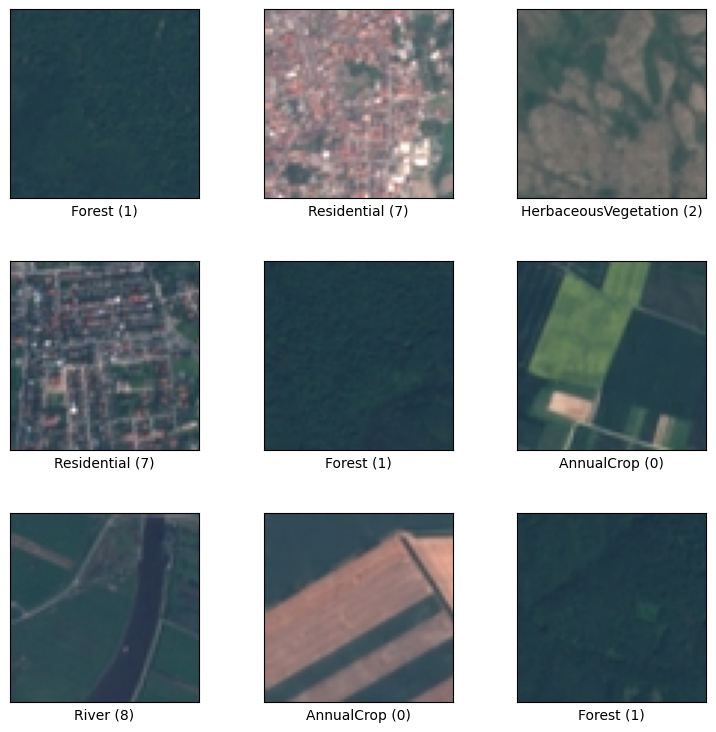

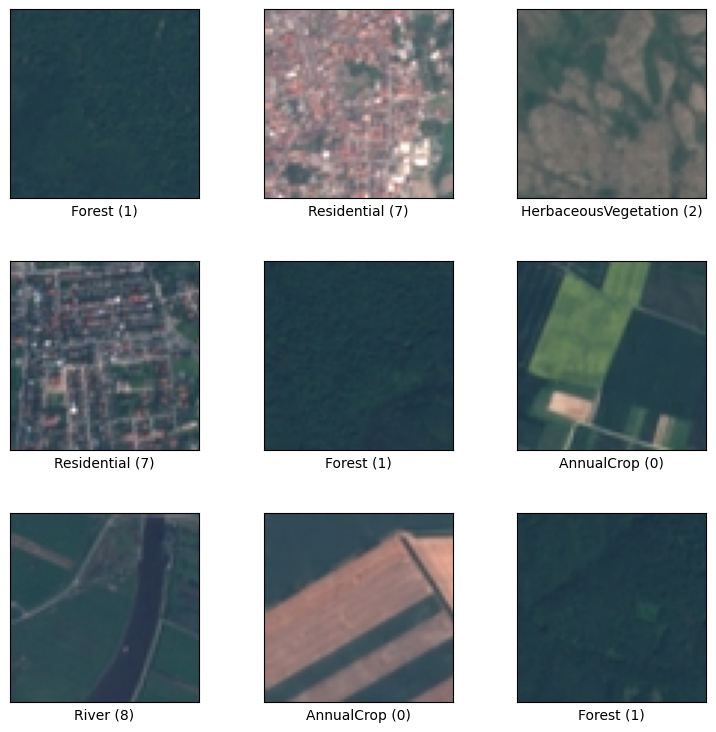

In [4]:
# 데이터 확인
tfds.show_examples(train_ds, info)

,image,label
0,,5 (Pasture)
1,,7 (Residential)
2,,0 (AnnualCrop)
3,,1 (Forest)
4,,0 (AnnualCrop)
5,,2 (HerbaceousVegetation)
6,,9 (SeaLake)
7,,8 (River)
8,,2 (HerbaceousVegetation)
9,,9 (SeaLake)

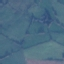
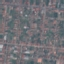
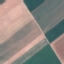
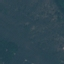
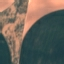
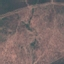
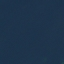
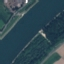
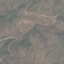
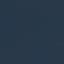

In [5]:
# as_dataframe 사용하여 샘플 출력
tfds.as_dataframe(valid_ds.take(10), info)

In [6]:
# 목표 클래스의 개수
NUM_CLASSES = info.features["label"].num_classes
print(NUM_CLASSES)

10


In [7]:
# 숫자 레이블을 활용하여 문자열 메타데이터로 변환
print(info.features["label"].int2str(6))

PermanentCrop


## 4-2. 데이터 전처리

In [8]:
# 데이터 전처리 파이프라인
BATCH_SIZE = 64
BUFFER_SIZE = 1000

def preprocess_data(image, label):
    image = tf.cast(image, tf.float32) / 255.   # 0~1 정규화, float32 변환
    return image, label

train_data = train_ds.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)
valid_data = valid_ds.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)

train_data = train_data.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
valid_data = valid_data.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

## 4-3. 모델 훈련 및 검증

In [11]:
# Sequential API를 사용하여 샘플 모델 생성

def build_model():

    model = tf.keras.Sequential([

        # Convolution 층
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Classifier 출력층
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
    ])

    return model

model = build_model()

In [10]:
# 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
history = model.fit(train_data,
                    validation_data=valid_data,
                    epochs=50)

Epoch 1/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 248s 721ms/step - accuracy: 0.3214 - loss: 2.0994 - val_accuracy: 0.4563 - val_loss: 1.6466
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 194s 573ms/step - accuracy: 0.5092 - loss: 1.3804 - val_accuracy: 0.7056 - val_loss: 0.9391
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 202s 576ms/step - accuracy: 0.5689 - loss: 1.2003 - val_accuracy: 0.6772 - val_loss: 0.9432
Epoch 4/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 207s 590ms/step - accuracy: 0.5870 - loss: 1.1287 - val_accuracy: 0.7213 - val_loss: 0.8176
Epoch 5/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 205s 600ms/step - accuracy: 0.6301 - loss: 1.0302 - val_accuracy: 0.7054 - val_loss: 0.8337
Epoch 6/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 201s 594ms/step - accuracy: 0.6496 - loss: 0.9770 - val_accuracy: 0.7357 - val_loss: 0.7716
Epoch 7/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 192s 563ms/step - accuracy: 0.6739 - loss: 0.9173 - val_accuracy: 0.7341 - val_loss: 0.7497
Epoch 8/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 207s 578ms/step - accuracy: 0.6955 -

으ㅏ르ㅏ으ㅏ

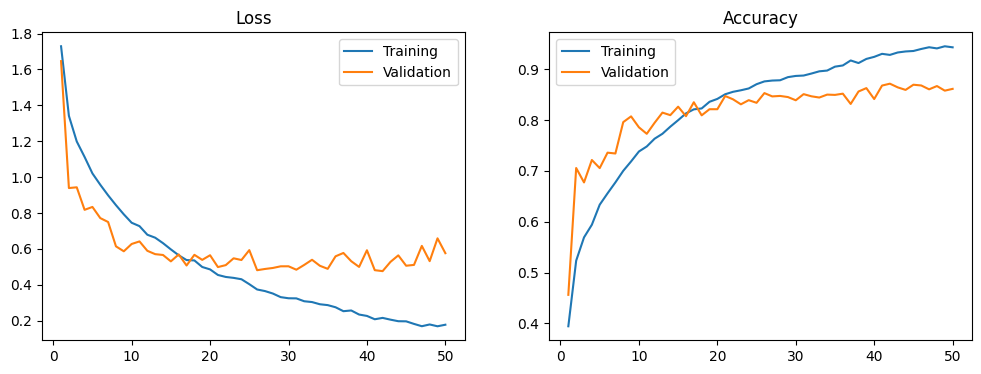

In [11]:
# 함수 정의 안해서 불러와서 해옴
def plot_loss_acc(history, epoch):

    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(range(1, epoch + 1), loss, label='Training')
    axes[0].plot(range(1, epoch + 1), val_loss, label='Validation')
    axes[0].legend(loc='best')
    axes[0].set_title('Loss')

    axes[1].plot(range(1, epoch + 1), acc, label='Training')
    axes[1].plot(range(1, epoch + 1), val_acc, label='Validation')
    axes[1].legend(loc='best')
    axes[1].set_title('Accuracy')

    plt.show()

# 손실함수, 정확도 그래프 그리기
plot_loss_acc(history, 50)

## 4-4. 데이터 증강

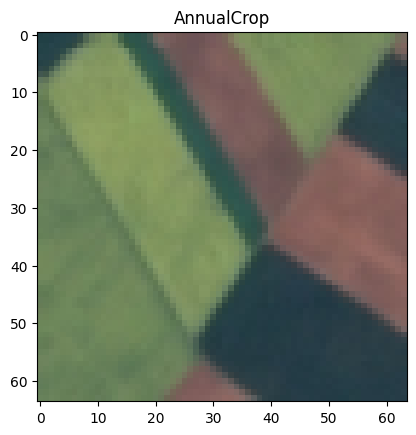

In [12]:
# 샘플 이미지
image_batch, label_batch = next(iter(train_data.take(1)))

image = image_batch[0]
label = label_batch[0].numpy()

plt.imshow(image)
plt.title(info.features["label"].int2str(label));

In [13]:
# 데이터 증강 전후를 비교하는 시각화 함수를 정의
def plot_augmentation(original, augmented):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(original)
    axes[0].set_title('Original')

    axes[1].imshow(augmented)
    axes[1].set_title('Augmented')

    plt.show()

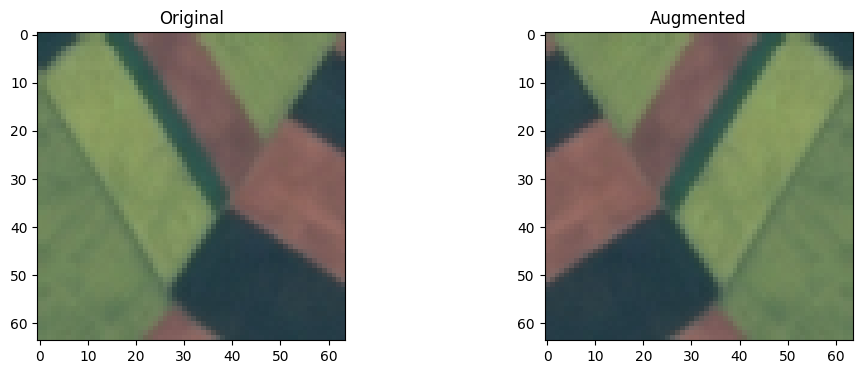

In [14]:
# 좌우 뒤집기
lr_flip = tf.image.flip_left_right(image)
plot_augmentation(image, lr_flip)

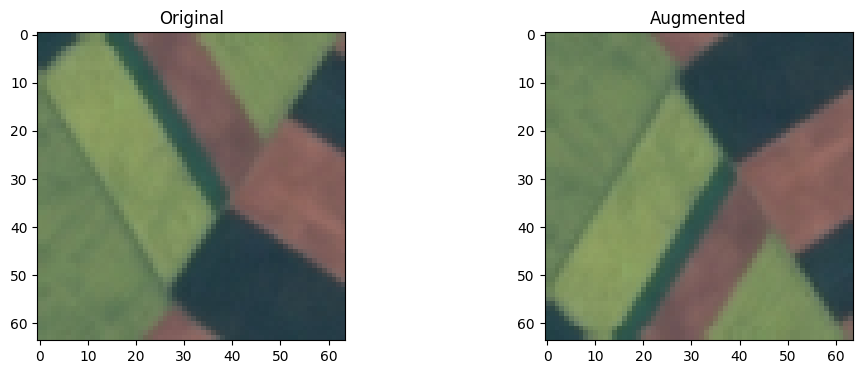

In [15]:
# 상하 뒤집기
ud_flip = tf.image.flip_up_down(image)
plot_augmentation(image, ud_flip)

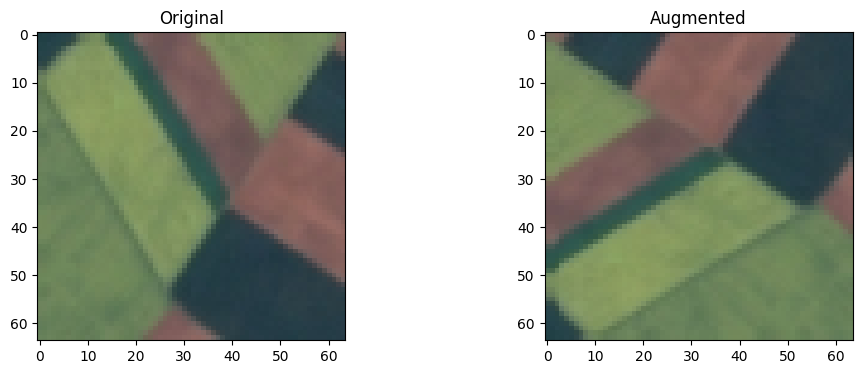

In [16]:
# 회전
rotate90 = tf.image.rot90(image)
plot_augmentation(image, rotate90)

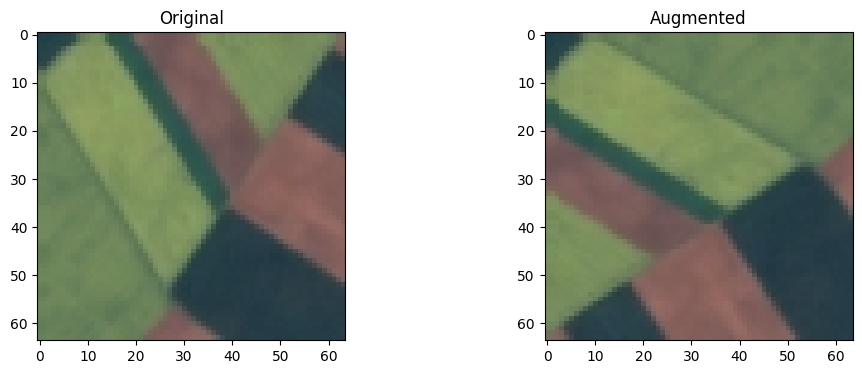

In [17]:
# transpose
transpose = tf.image.transpose(image)
plot_augmentation(image, transpose)

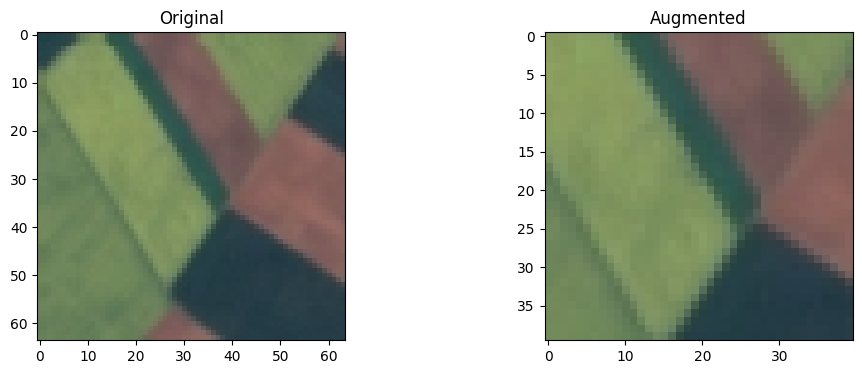

In [18]:
# 이미지 자르기 1
crop1 = tf.image.central_crop(image, central_fraction=0.6)
plot_augmentation(image, crop1)

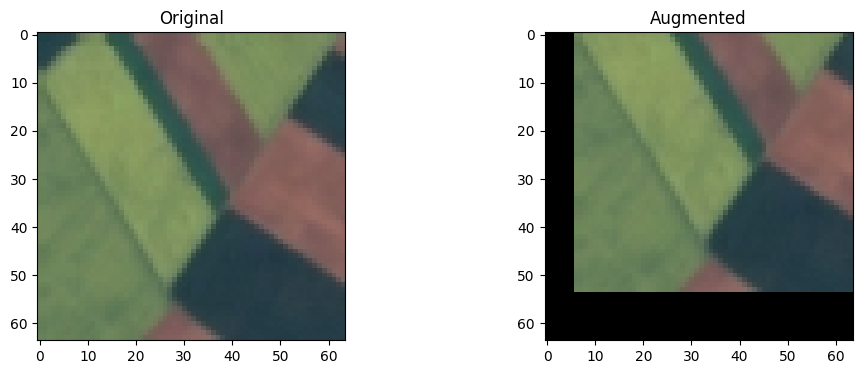

In [19]:
# 이미지 자르기 2
img = tf.image.resize_with_crop_or_pad(image, 64 + 20, 64 + 20) # 사이즈 키우기
crop2 = tf.image.random_crop(img, size=[64, 64, 3])
plot_augmentation(image, crop2)

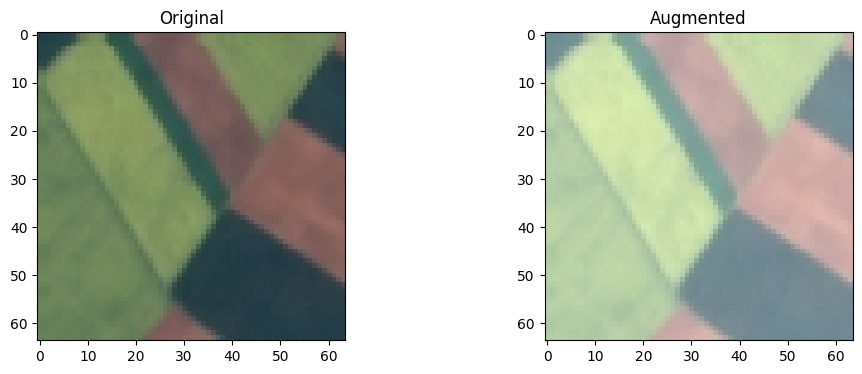

In [20]:
# 이미지 밝기
brightness = tf.image.adjust_brightness(image, delta=0.3)
plot_augmentation(image, brightness)

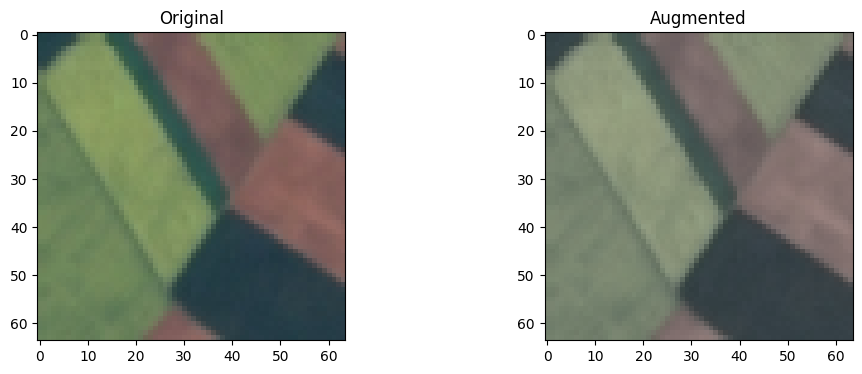

In [21]:
# 이미지 채도
saturation = tf.image.adjust_saturation(image, saturation_factor=0.5)
plot_augmentation(image, saturation)

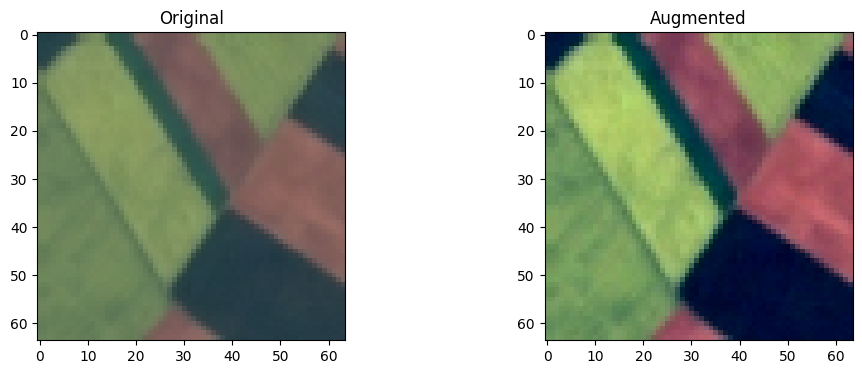

In [22]:
# 이미지 대비
contrast = tf.image.adjust_contrast(image, contrast_factor=2)
plot_augmentation(image, contrast)

In [9]:
# 이미지 증강 전처리
def data_augmentation(image, label):

    image = tf.image.random_flip_left_right(image) # 좌우 반전
    image = tf.image.random_flip_up_down(image) # 상하 반전
    image = tf.image.random_brightness(image, max_delta=0.3) # 밝기 변화
    image = tf.image.random_crop(image, size=[64, 64, 3])

    image = tf.cast(image, tf.float32) / 255.   # 0~1 정규화

    return image, label

train_aug = train_ds.map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
valid_aug = valid_ds.map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)

train_aug = train_aug.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
valid_aug = valid_aug.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

print(train_aug)
print(valid_aug)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


In [12]:
# 모델 생성
aug_model = build_model()

# 모델 컴파일
aug_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
aug_history = aug_model.fit(train_aug,
                            validation_data=valid_aug,
                            epochs=50)

Epoch 1/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.2255 - loss: 2.2723 - val_accuracy: 0.2972 - val_loss: 1.8361
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.3394 - loss: 1.6961 - val_accuracy: 0.4300 - val_loss: 1.5304
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.3763 - loss: 1.5774 - val_accuracy: 0.4157 - val_loss: 1.5248
Epoch 4/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.4021 - loss: 1.5230 - val_accuracy: 0.5341 - val_loss: 1.2767
Epoch 5/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4431 - loss: 1.4346 - val_accuracy: 0.5222 - val_loss: 1.2890
Epoch 6/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.4671 - loss: 1.4112 - val_accuracy: 0.5972 - val_loss: 1.1334
Epoch 7/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4985 - loss: 1.3492 - val_accuracy: 0.6509 - val_loss: 1.0550
Epoch 8/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5187 - loss: 1.3025 - val_a

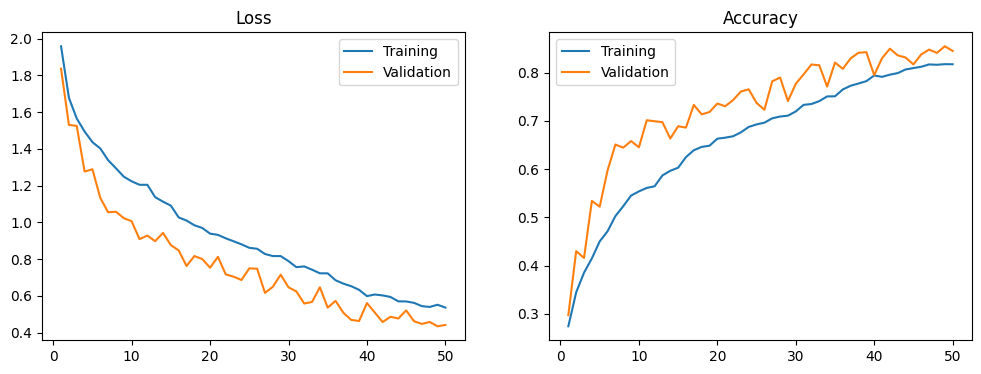

In [14]:
# 함수 정의 안해서 불러와서 해옴
def plot_loss_acc(history, epoch):

    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(range(1, epoch + 1), loss, label='Training')
    axes[0].plot(range(1, epoch + 1), val_loss, label='Validation')
    axes[0].legend(loc='best')
    axes[0].set_title('Loss')

    axes[1].plot(range(1, epoch + 1), acc, label='Training')
    axes[1].plot(range(1, epoch + 1), val_acc, label='Validation')
    axes[1].legend(loc='best')
    axes[1].set_title('Accuracy')

    plt.show()

# 손실함수, 정확도 그래프 그리기
plot_loss_acc(aug_history, 50)

## 4-5. ResNet 사전 학습 모델

In [17]:
#ImportError: cannot import name 'wrappers' from 'tensorflow.python.keras.layers' 오류로 추가
# ImportError: if graphviz or pydot are not available.가 위에 있어서 graphviz 설치로 해결 시도
# 참고 포스팅: https://frhyme.github.io/python-libs/graphviz_using_graphviz_in_colab/
## using graphviz
!apt-get -qq install -y graphviz && pip install -q pydot
import pydot
## 아래 있는것은 필수는 아닌데, 가끔 에러가 생길 때가 있어서, 그냥 같이 해줌.
!apt-get install graphviz libgraphviz-dev pkg-config
!pip install pygraphviz
import pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
The following additional packages will be installed:
  libgail-common libgail18 libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxdot4
Suggested packages:
  gvfs
The following packages will be REMOVED:
  pkgconf r-base-dev
The following NEW packages will be installed:
  libgail-common libgail18 libgraphviz-dev libgtk2.0-0 libgtk2.0-bin libgtk2.0-common
  libgvc6-plugins-gtk librsvg2-common libxdot4 pkg-config
0 upgraded, 10 newly installed, 2 to remove and 49 not upgraded.
Need to get 2,482 kB of archives.
After this operation, 7,670 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 pkg-config a

In [20]:
import os
os.environ["PATH"] += os.pathsep + '/usr/bin'

In [19]:
sudo apt-get install graphviz

SyntaxError: invalid syntax (<ipython-input-19-ed26e7b4d7d8>, line 1)

In [22]:
# Pre-trained 모델을 사전 학습된 가중치와 함께 가져오기
from tensorflow.keras.applications import ResNet50V2


pre_trained_base = ResNet50V2(include_top=False,
                               weights='imagenet',
                               input_shape=[64, 64, 3])
,
# 사전 학습된 가중치를 업데이트 되지 않도록 설정
pre_trained_base.trainable = False

# 모델 구조 시각화
from tensorflow.python.keras.utils.vis_utils import plot_model
from tensorflow.keras.utils import plot_model
plot_model(pre_trained_base, show_shapes=True, show_layer_names=True, to_file='resnet50.png')

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.537852 to fit



In [23]:
# Top 층에 Classifier 추가

def build_trainsfer_classifier():

    model = tf.keras.Sequential([

        # Pre-trained Base
        pre_trained_base,
        # Classifier 출력층
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
    ])

    return model

# 모델 구조
tc_model = build_trainsfer_classifier()
tc_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)              │ (None, 2, 2, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,622,410 (93.93 MB)

 Trainable params: 1,057,610 (4.03 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [24]:
# 모델 컴파일
tc_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
tc_history = tc_model.fit(train_aug,
                          validation_data=valid_aug,
                          epochs=50)

Epoch 1/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 32s 58ms/step - accuracy: 0.5907 - loss: 1.2594 - val_accuracy: 0.8017 - val_loss: 0.5904
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.7639 - loss: 0.7362 - val_accuracy: 0.8267 - val_loss: 0.5117
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7850 - loss: 0.6650 - val_accuracy: 0.8383 - val_loss: 0.4877
Epoch 4/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8089 - loss: 0.5854 - val_accuracy: 0.8394 - val_loss: 0.4749
Epoch 5/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8173 - loss: 0.5574 - val_accuracy: 0.8474 - val_loss: 0.4540
Epoch 6/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.8204 - loss: 0.5475 - val_accuracy: 0.8465 - val_loss: 0.4534
Epoch 7/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8301 - loss: 0.5262 - val_accuracy: 0.8502 - val_loss: 0.4387
Epoch 8/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8399 - loss: 0.5014 - val_ac

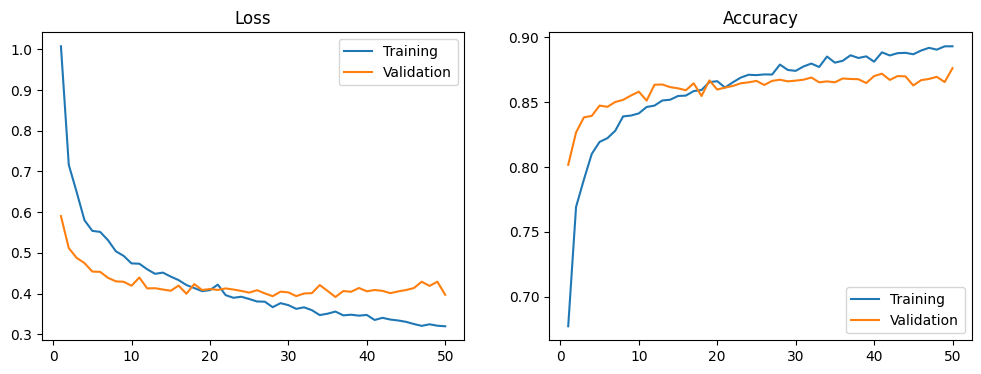

In [25]:
# 손실함수, 정확도 그래프 그리기
plot_loss_acc(tc_history, 50)

**4-1. 텐서플로 데이터셋 로드**  
데이터를 로드해오는 과정. 참고로 코랩에서 실행시 첫시도엔 항상 런타임 해제되는 오류가 있었음.  런타임 다시 실행시 해결 가능  
**4-2. 데이터 전처리**  
데이터 전처리 과정을 하나의 파이프라인으로 정리  
- 데이터 정규화
- `BUFFER_SIZE`, `BATCH_SIZE` 설정으로 배치 구성  

**4-3. 모델 훈련 및 검증**  
- `Sequential` API로 모델 생성  
- 배치정규화, Conv2D, Maxpooling 반복으로 특성 추출  
- Flatten한 후에 Dense, Dropout으로 연결  
- adam optimizer 설정  

**4-4. 데이터 증강**  
: 이미지 데이터 처리 시에 모델의 robust한 성능을 확보하기 위한 기법,  
이미지에 여러 변형을 주어 훈련 데이터의 다양성 확보    
- 좌우 상하 뒤집기, 회전하기 도치, 잘라내기, 밝기, 대비, 채도 조정 등 가능

**4-5. ResNet 사전학습 모델**  
: 사전에 학습된 모델로, 해당 모델의 끝단에 위치한 층에 위성 이미지를 분류할 수 있는 최종 분류기를 추가하여 모델 구성  
-> `include_top = False`로 지정해야 Top층을 우리가 원하는 위성 이미지에 대한 분류기로 고쳐서 사용이 가능